# Naive Bayes (NB)
Naive Bayes is een eenvoudige maar krachtige probabilistische classificatiemethode gebaseerd op de Bayesiaanse statistiek. Het model maakt gebruik van de Bayes' theorema om de waarschijnlijkheid te berekenen dat een gegeven invoer tot een bepaalde klasse behoort, op basis van de kenmerken van de invoer. Het "naive" aspect van het model verwijst naar de aanname dat alle kenmerken onafhankelijk zijn van elkaar, wat in de praktijk vaak niet het geval is, maar toch verrassend goede resultaten kan opleveren. Naive Bayes is vooral effectief bij tekstclassificatieproblemen, zoals spamdetectie en sentimentanalyse, vanwege zijn efficiëntie en vermogen om goed te presteren met beperkte trainingsdata.

In [1]:
import sys
import os

# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from utils.libs_generic_functions import LibsDataPreprocessor, LibsDataLoader
from utils.baseline_correction_functions import BaselineCorrector, analyze_correction_quality, print_quality_report
from utils.pca_analysis_functions import PCAAnalyzer, quick_pca_analysis
from utils.lda_analysis_functions import quick_lda_analysis
from utils.normalization_functions import Normalizer
from utils.saturation_functions import apply_voigt_saturation_correction

In [2]:
df = pd.read_csv('../data/csv/processed_data.csv')

In [3]:
Preprocessor = LibsDataPreprocessor()
X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, wavelength_columns = Preprocessor.prepare_ml_data(df)

PREPARING DATA FOR MACHINE LEARNING
Original dataset shape: (51453, 8004)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Splitting complete dataset (test_size=0.2, random_state=42)...
Training dataset shape: (41162, 8004)
Test dataset shape: (10291, 8004)
Training target distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test target distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64

Identified 8001 wavelength columns
Extracting features and targets from training set...
Extracting features and targets from test set...
Converting features to numeric...
Encoding labels...

Final results:
Training features shape: (41162, 8001)
Test features shape: (10291, 8001)
Label classes: ['innerliner' 'sidewall' 'tread']
Training label distribution: [13808 13005 14349]
Test label distribution: [3452 3252 3587]


In [4]:
# Remove wavelengths from df that are not in NIST top 50% data
print("=" * 70)
print("FILTERING DF TO ONLY INCLUDE NIST TOP 50% WAVELENGTHS")
print("=" * 70)

# Load NIST top 50% wavelengths
nist_top_50_percent_df = pd.read_csv('../data/csv/nist_top_50_percent_wavelengths.csv')

# Extract all unique wavelengths from nist_top_50_percent_df
nist_wavelengths_set = set()
for column in nist_top_50_percent_df.columns:
    # Get wavelengths from this element column, drop NaN values
    element_wavelengths = nist_top_50_percent_df[column].dropna().tolist()
    nist_wavelengths_set.update([float(wl) for wl in element_wavelengths if pd.notna(wl)])

print(f"NIST wavelengths found: {len(nist_wavelengths_set)} unique wavelengths")
print(f"NIST wavelength range: {min(nist_wavelengths_set):.1f} - {max(nist_wavelengths_set):.1f} nm")

# Get wavelength columns from df (exclude metadata columns)
metadata_columns = ['tire_number', 'origin', 'measurement_id']
all_wavelength_columns = [col for col in df.columns if col not in metadata_columns]

print(f"\nOriginal df wavelengths: {len(all_wavelength_columns)}")
print(f"Original df wavelength range: {min([float(col) for col in all_wavelength_columns]):.1f} - {max([float(col) for col in all_wavelength_columns]):.1f} nm")

# Find wavelengths to keep (with tolerance for matching)
tolerance = 0.1  # 0.1 nm tolerance
wavelengths_to_keep = []

for col in all_wavelength_columns:
    col_wl = float(col)
    # Check if this wavelength is close to any NIST wavelength
    for nist_wl in nist_wavelengths_set:
        if abs(col_wl - nist_wl) <= tolerance:
            wavelengths_to_keep.append(col)
            break

print(f"\nWavelengths to keep: {len(wavelengths_to_keep)}")
print(f"Wavelengths to remove: {len(all_wavelength_columns) - len(wavelengths_to_keep)}")
print(f"Reduction: {((len(all_wavelength_columns) - len(wavelengths_to_keep)) / len(all_wavelength_columns)) * 100:.1f}%")

# Create filtered dataframe
columns_to_keep = metadata_columns + wavelengths_to_keep
df_filtered = df[columns_to_keep].copy()

print(f"\n✅ Filtered DataFrame created:")
print(f"   Original shape: {df.shape}")
print(f"   Filtered shape: {df_filtered.shape}")
print(f"   Columns removed: {df.shape[1] - df_filtered.shape[1]}")

# Show some examples of kept wavelengths
print(f"\nFirst 10 wavelengths kept:")
for i, wl in enumerate(wavelengths_to_keep[:10]):
    print(f"   {wl} nm")

if len(wavelengths_to_keep) > 10:
    print(f"   ... and {len(wavelengths_to_keep) - 10} more")

# Update the df variable to the filtered version
nist_filtered_df = df_filtered.copy()

print(f"\n🎯 df has been updated to only contain NIST top 50% wavelengths")
print(f"   New df shape: {nist_filtered_df.shape}")

FILTERING DF TO ONLY INCLUDE NIST TOP 50% WAVELENGTHS
NIST wavelengths found: 347 unique wavelengths
NIST wavelength range: 202.4 - 939.7 nm

Original df wavelengths: 8001
Original df wavelength range: 200.0 - 1000.0 nm

Wavelengths to keep: 377
Wavelengths to remove: 7624
Reduction: 95.3%

✅ Filtered DataFrame created:
   Original shape: (51453, 8004)
   Filtered shape: (51453, 380)
   Columns removed: 7624

First 10 wavelengths kept:
   202.3 nm
   202.4 nm
   202.5 nm
   202.6 nm
   202.7 nm
   206.1 nm
   206.2 nm
   212.3 nm
   212.4 nm
   212.5 nm
   ... and 367 more

🎯 df has been updated to only contain NIST top 50% wavelengths
   New df shape: (51453, 380)


In [5]:
nist_X_train, nist_X_test, nist_y_train_encoded, nist_y_test_encoded, label_encoder, wavelength_columns = Preprocessor.prepare_ml_data(nist_filtered_df) 

PREPARING DATA FOR MACHINE LEARNING
Original dataset shape: (51453, 380)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Splitting complete dataset (test_size=0.2, random_state=42)...
Training dataset shape: (41162, 380)
Test dataset shape: (10291, 380)
Training target distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test target distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64

Identified 377 wavelength columns
Extracting features and targets from training set...
Extracting features and targets from test set...
Converting features to numeric...
Encoding labels...

Final results:
Training features shape: (41162, 377)
Test features shape: (10291, 377)
Label classes: ['innerliner' 'sidewall' 'tread']
Training label distribution: [13808 13005 14349]
Test label distribution: [3452 3252 3587]


In [6]:
# Convert column names to wavelengths and filter
wavelength_values = [float(col) for col in X_train.columns]
selected_indices = []
selected_wavelengths = []

for i, wl in enumerate(wavelength_values):
    if (670 <= wl <= 750) or (950 <= wl <= 960):
        selected_indices.append(i)
        selected_wavelengths.append(wl)

# Create filtered datasets from subset
X_train_ig = X_train.iloc[:, selected_indices]
X_test_ig = X_test.iloc[:, selected_indices]

# Comprehensive Naive Bayes Analysis
In deze sectie voeren we een uitgebreide Naive Bayes analyse uit, vergelijkbaar met onze andere ML analyses. We testen verschillende Naive Bayes varianten en vergelijken de prestaties met en zonder dimensionaliteitsreductie. Naive Bayes is bijzonder interessant voor spectroscopische data vanwege zijn probabilistische aanpak en efficiëntie.

## 1. Naive Bayes op originele features

In [7]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import MinMaxScaler
import time
import tracemalloc
import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the measure_model_details import
from utils.measure_model_details import (
    measure_training_time, measure_inference_time, get_memory_usage
)

def comprehensive_naive_bayes_evaluation():
    """
    Comprehensive Naive Bayes evaluation across 4 different feature sets:
    1. PCA reduced features
    2. LDA reduced features  
    3. Information Gain selected wavelengths
    4. NIST emission line selected features
    """
    
    print("=" * 80)
    print("COMPREHENSIVE NAIVE BAYES EVALUATION")
    print("=" * 80)
    
    # Initialize results storage
    evaluation_results = {}
    
    # Define hyperparameter grids for different NB variants
    param_grids = {
        'gaussian': {'var_smoothing': [1e-9, 1e-7, 1e-5, 1e-3]},
    }
    
    print(f"Testing multiple Naive Bayes variants:")
    print(f"   • GaussianNB: {len(param_grids['gaussian']['var_smoothing'])} var_smoothing values")
    print(f"Cross-validation folds: 5")
    print()
    
    return param_grids, evaluation_results

def evaluate_naive_bayes_configuration(X_train, X_test, y_train, y_test, 
                                     config_name, param_grids, label_encoder,
                                     n_runs=3):
    """
    Evaluate a single Naive Bayes configuration with comprehensive metrics.
    
    Parameters:
    -----------
    X_train, X_test : array-like
        Training and test features
    y_train, y_test : array-like
        Training and test labels
    config_name : str
        Name of the configuration being tested
    param_grids : dict
        Hyperparameter grids for different NB variants
    label_encoder : LabelEncoder
        Label encoder for classification reports
    n_runs : int, default=3
        Number of runs for timing measurements
        
    Returns:
    --------
    dict : Comprehensive evaluation results
    """
    
    print(f"\n{'='*60}")
    print(f"EVALUATING: {config_name.upper()}")
    print(f"{'='*60}")
    print(f"Training shape: {X_train.shape}")
    print(f"Test shape: {X_test.shape}")
    
    # Track memory usage
    tracemalloc.start()
    memory_before = get_memory_usage()
    
    # Prepare different data representations for different NB variants
    print(f"\n📋 Data Preprocessing for NB variants...")
    
    # 1. Original/Scaled data (for GaussianNB)
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    
    # Define NB variants with their appropriate data
    nb_variants = {
        'GaussianNB': {
            'model': GaussianNB(),
            'data': (X_train_scaled, X_test_scaled),
            'param_grid': param_grids['gaussian']
        },
    }
    
    # 1. TEST ALL NB VARIANTS AND FIND BEST
    print(f"\n🔍 Testing NB Variants with Hyperparameter Optimization...")
    
    variant_results = {}
    optimization_start = time.perf_counter()
    
    for variant_name, config in nb_variants.items():
        print(f"   Testing {variant_name}...")
        
        model = config['model']
        X_train_var, X_test_var = config['data']
        param_grid = config['param_grid']
        
        # Grid search for this variant
        grid_search = GridSearchCV(
            model,
            param_grid,
            cv=5,
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )
        
        grid_search.fit(X_train_var, y_train)
        
        # Store results
        variant_results[variant_name] = {
            'best_score': grid_search.best_score_,
            'best_params': grid_search.best_params_,
            'best_model': grid_search.best_estimator_,
            'data': (X_train_var, X_test_var)
        }
        
        print(f"     Best CV score: {grid_search.best_score_:.4f}")
        print(f"     Best params: {grid_search.best_params_}")
    
    # Find best variant
    best_variant_name = max(variant_results.keys(), 
                           key=lambda x: variant_results[x]['best_score'])
    best_variant_config = variant_results[best_variant_name]
    
    optimization_end = time.perf_counter()
    optimization_time = optimization_end - optimization_start
    
    print(f"\n🏆 Best variant: {best_variant_name}")
    print(f"   Best CV score: {best_variant_config['best_score']:.4f}")
    print(f"   Best parameters: {best_variant_config['best_params']}")
    print(f"   Total optimization time: {optimization_time:.2f} seconds")
    
    # 2. TRAINING TIME MEASUREMENT
    print(f"\n⏱️  Training Time Measurement ({n_runs} runs)...")
    
    # Get best model and data
    final_model = best_variant_config['best_model']
    X_train_final, X_test_final = best_variant_config['data']
    
    # Create new instance for clean timing measurement
    final_model_clean = type(final_model)(**final_model.get_params())
    
    # Measure training time
    training_results = measure_training_time(
        final_model_clean, X_train_final, y_train, n_runs=n_runs
    )
    
    print(f"   Mean training time: {training_results['mean_time']:.4f} ± {training_results['std_time']:.4f} seconds")
    print(f"   Memory increase: {training_results['memory_increase_mean']:.2f} MB")
    
    # Use the trained model from timing measurement
    trained_model = training_results['trained_model']
    
    # 3. PREDICTION AND PERFORMANCE METRICS
    print(f"\n📊 Performance Evaluation...")
    
    # Make predictions
    y_train_pred = trained_model.predict(X_train_final)
    y_test_pred = trained_model.predict(X_test_final)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # F1 scores (macro and weighted)
    train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
    test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
    train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
    test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
    
    print(f"   Training Accuracy: {train_accuracy:.4f}")
    print(f"   Test Accuracy: {test_accuracy:.4f}")
    print(f"   Training F1 (macro): {train_f1_macro:.4f}")
    print(f"   Test F1 (macro): {test_f1_macro:.4f}")
    print(f"   Training F1 (weighted): {train_f1_weighted:.4f}")
    print(f"   Test F1 (weighted): {test_f1_weighted:.4f}")
    
    # 4. INFERENCE TIME MEASUREMENT
    print(f"\n⚡ Inference Time Measurement...")
    
    inference_results = measure_inference_time(trained_model, X_test_final, n_runs=10)
    
    print(f"   Mean inference time: {inference_results['mean_time']*1000:.2f} ± {inference_results['std_time']*1000:.2f} ms")
    print(f"   Time per sample: {inference_results['mean_time']*1000/len(X_test_final):.4f} ms")
    print(f"   Samples per second: {len(X_test_final)/inference_results['mean_time']:.0f}")
    
    # 5. MEMORY USAGE ANALYSIS
    memory_after = get_memory_usage()
    memory_peak = tracemalloc.get_traced_memory()[1] / 1024 / 1024  # Convert to MB
    tracemalloc.stop()
    
    print(f"\n💾 Memory Usage Analysis...")
    print(f"   Memory before: {memory_before:.2f} MB")
    print(f"   Memory after: {memory_after:.2f} MB")
    print(f"   Memory increase: {memory_after - memory_before:.2f} MB")
    print(f"   Peak memory usage: {memory_peak:.2f} MB")
    
    # 6. MODEL CHARACTERISTICS
    print(f"\n🧠 Naive Bayes Model Characteristics...")
    print(f"   Best variant: {best_variant_name}")
    print(f"   Number of classes: {len(trained_model.classes_)}")
    print(f"   Number of features: {X_train_final.shape[1]}")
    
    
    # Calculate model complexity
    n_parameters = 0
    if hasattr(trained_model, 'theta_'):
        n_parameters = trained_model.theta_.size
    elif hasattr(trained_model, 'feature_log_prob_'):
        n_parameters = trained_model.feature_log_prob_.size
    
    model_memory_estimate = (n_parameters * 8) / (1024 * 1024)  # 8 bytes per float64
    
    print(f"   Estimated parameters: {n_parameters}")
    print(f"   Estimated model size: {model_memory_estimate:.2f} MB")
    
    # 7. PROBABILISTIC ANALYSIS
    print(f"\n🎲 Probabilistic Predictions Analysis...")
    
    # Get prediction probabilities
    y_pred_proba = trained_model.predict_proba(X_test_final)
    
    # Calculate confidence metrics
    max_probabilities = np.max(y_pred_proba, axis=1)
    mean_confidence = np.mean(max_probabilities)
    confidence_std = np.std(max_probabilities)
    
    print(f"   Mean prediction confidence: {mean_confidence:.4f}")
    print(f"   Confidence std deviation: {confidence_std:.4f}")
    print(f"   High confidence predictions (>0.9): {np.sum(max_probabilities > 0.9)}/{len(max_probabilities)} ({100*np.sum(max_probabilities > 0.9)/len(max_probabilities):.1f}%)")
    
    # 8. CLASSIFICATION REPORT
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, digits=4))
    
    # 9. CONFUSION MATRIX VISUALIZATION
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix - {config_name} ({best_variant_name})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    # 10. VARIANT COMPARISON VISUALIZATION
    print(f"\n📈 NB Variants Performance Comparison...")
    
    # Test all variants on test data for comparison
    variant_test_scores = {}
    for variant_name, config in variant_results.items():
        model = config['best_model']
        X_train_var, X_test_var = config['data']
        y_pred_var = model.predict(X_test_var)
        test_acc = accuracy_score(y_test, y_pred_var)
        variant_test_scores[variant_name] = test_acc
        print(f"   {variant_name}: {test_acc:.4f}")
    
    # Plot variant comparison
    plt.figure(figsize=(10, 6))
    variants = list(variant_test_scores.keys())
    scores = list(variant_test_scores.values())
    colors = ['lightblue', 'lightgreen', 'orange', 'pink'][:len(variants)]
    
    bars = plt.bar(variants, scores, color=colors, alpha=0.7)
    plt.title(f'Naive Bayes Variants Performance - {config_name}')
    plt.ylabel('Test Accuracy')
    plt.xlabel('NB Variant')
    plt.ylim(0, 1.1)
    
    # Highlight best variant
    best_idx = variants.index(best_variant_name)
    bars[best_idx].set_color('red')
    bars[best_idx].set_alpha(1.0)
    
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Compile all results
    results = {
        'config_name': config_name,
        'data_shape': X_train.shape,
        'n_features': X_train.shape[1],
        
        # Best variant results
        'best_variant': best_variant_name,
        'best_params': best_variant_config['best_params'],
        'best_cv_score': best_variant_config['best_score'],
        'optimization_time': optimization_time,
        'all_variant_scores': variant_test_scores,
        
        # Performance metrics
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'train_f1_macro': train_f1_macro,
        'test_f1_macro': test_f1_macro,
        'train_f1_weighted': train_f1_weighted,
        'test_f1_weighted': test_f1_weighted,
        
        # Timing results
        'training_time_mean': training_results['mean_time'],
        'training_time_std': training_results['std_time'],
        'inference_time_mean': inference_results['mean_time'],
        'inference_time_std': inference_results['std_time'],
        'inference_time_per_sample': inference_results['mean_time'] / len(X_test_final),
        'samples_per_second': len(X_test_final) / inference_results['mean_time'],
        
        # Memory results
        'memory_before': memory_before,
        'memory_after': memory_after,
        'memory_increase': memory_after - memory_before,
        'memory_peak': memory_peak,
        'training_memory_increase': training_results['memory_increase_mean'],
        'model_memory_estimate': model_memory_estimate,
        
        # Model characteristics
        'n_classes': len(trained_model.classes_),
        'n_parameters': n_parameters,
        'mean_confidence': mean_confidence,
        'confidence_std': confidence_std,
        'high_confidence_ratio': np.sum(max_probabilities > 0.9) / len(max_probabilities),
        
        # Model object
        'trained_model': trained_model,
        'predictions': y_test_pred,
        'prediction_probabilities': y_pred_proba
    }
    
    # Clean up memory
    gc.collect()
    
    return results

# Now run the comprehensive evaluation
param_grids, evaluation_results = comprehensive_naive_bayes_evaluation()

COMPREHENSIVE NAIVE BAYES EVALUATION
Testing multiple Naive Bayes variants:
   • GaussianNB: 4 var_smoothing values
Cross-validation folds: 5




🚀 Starting Test 1: NIST Emission Line Features

EVALUATING: NIST EMISSION LINES
Training shape: (41162, 377)
Test shape: (10291, 377)

📋 Data Preprocessing for NB variants...

🔍 Testing NB Variants with Hyperparameter Optimization...
   Testing GaussianNB...
     Best CV score: 0.5503
     Best params: {'var_smoothing': 0.001}

🏆 Best variant: GaussianNB
   Best CV score: 0.5503
   Best parameters: {'var_smoothing': 0.001}
   Total optimization time: 9.17 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 0.2642 ± 0.0029 seconds
   Memory increase: 0.02 MB

📊 Performance Evaluation...
   Training Accuracy: 0.5503
   Test Accuracy: 0.5517
   Training F1 (macro): 0.5447
   Test F1 (macro): 0.5464
   Training F1 (weighted): 0.5454
   Test F1 (weighted): 0.5471

⚡ Inference Time Measurement...
   Mean inference time: 86.54 ± 0.59 ms
   Time per sample: 0.0084 ms
   Samples per second: 118920

💾 Memory Usage Analysis...
   Memory before: 4310.28 MB
   Memory after: 4

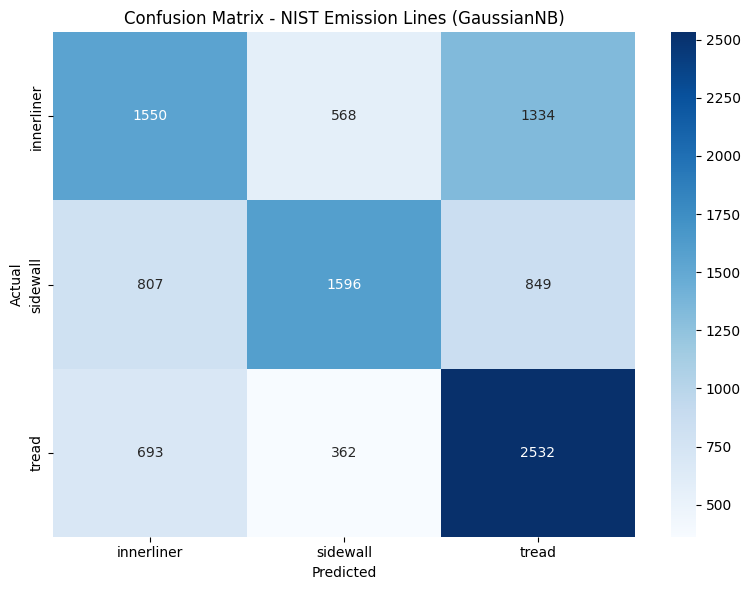


📈 NB Variants Performance Comparison...
   GaussianNB: 0.5517


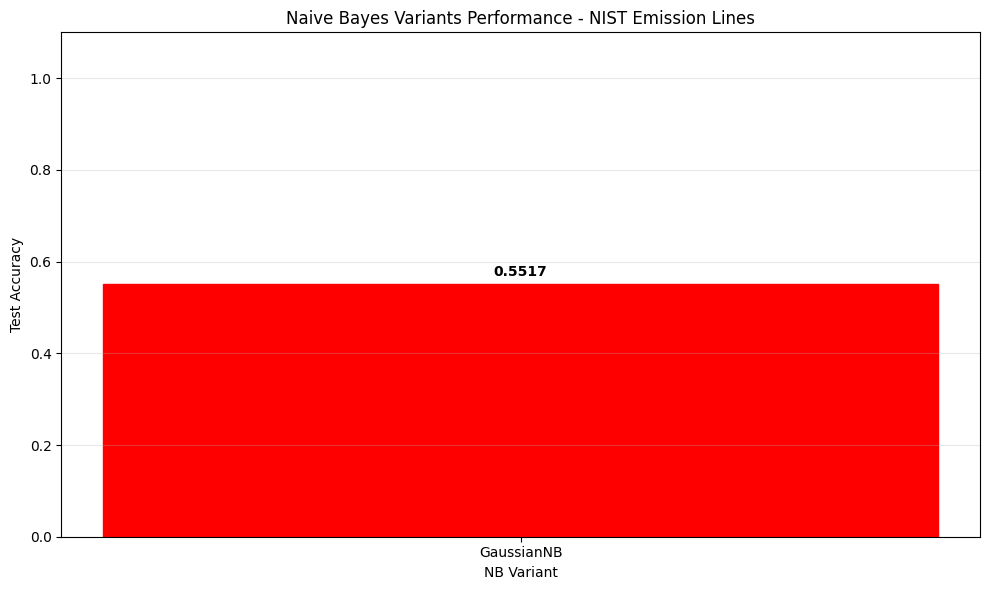

In [8]:
#Test 1: NIST Emission Line Features
print("\n🚀 Starting Test 1: NIST Emission Line Features")
nist_results = evaluate_naive_bayes_configuration(
    nist_X_train, nist_X_test, nist_y_train_encoded, nist_y_test_encoded,
    "NIST Emission Lines", param_grids, label_encoder
)
evaluation_results['NIST'] = nist_results


🚀 Starting Test 2: Information Gain Selected Features

EVALUATING: INFORMATION GAIN SELECTION
Training shape: (41162, 902)
Test shape: (10291, 902)

📋 Data Preprocessing for NB variants...

🔍 Testing NB Variants with Hyperparameter Optimization...
   Testing GaussianNB...
     Best CV score: 0.6554
     Best params: {'var_smoothing': 1e-09}

🏆 Best variant: GaussianNB
   Best CV score: 0.6554
   Best parameters: {'var_smoothing': 1e-09}
   Total optimization time: 10.07 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 0.6758 ± 0.0223 seconds
   Memory increase: 0.27 MB

📊 Performance Evaluation...
   Training Accuracy: 0.6562
   Test Accuracy: 0.6582
   Training F1 (macro): 0.6522
   Test F1 (macro): 0.6541
   Training F1 (weighted): 0.6528
   Test F1 (weighted): 0.6547

⚡ Inference Time Measurement...
   Mean inference time: 267.81 ± 15.58 ms
   Time per sample: 0.0260 ms
   Samples per second: 38427

💾 Memory Usage Analysis...
   Memory before: 4360.94 MB
  

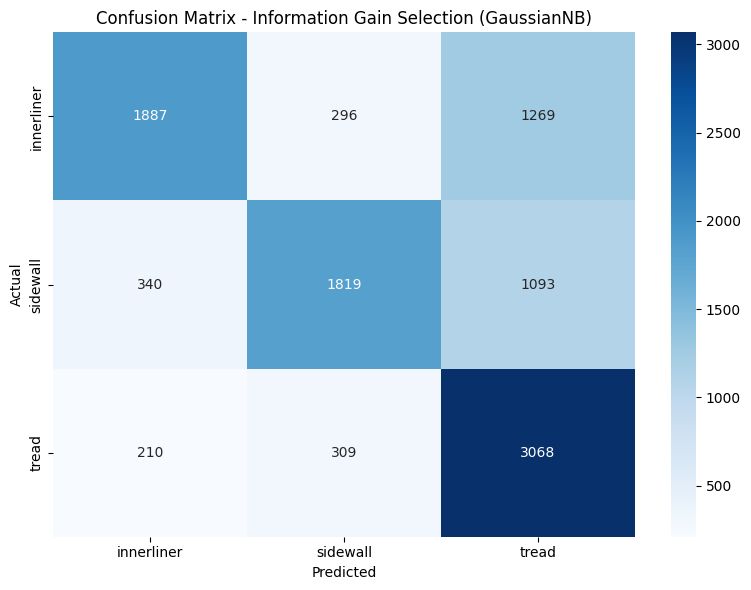


📈 NB Variants Performance Comparison...
   GaussianNB: 0.6582


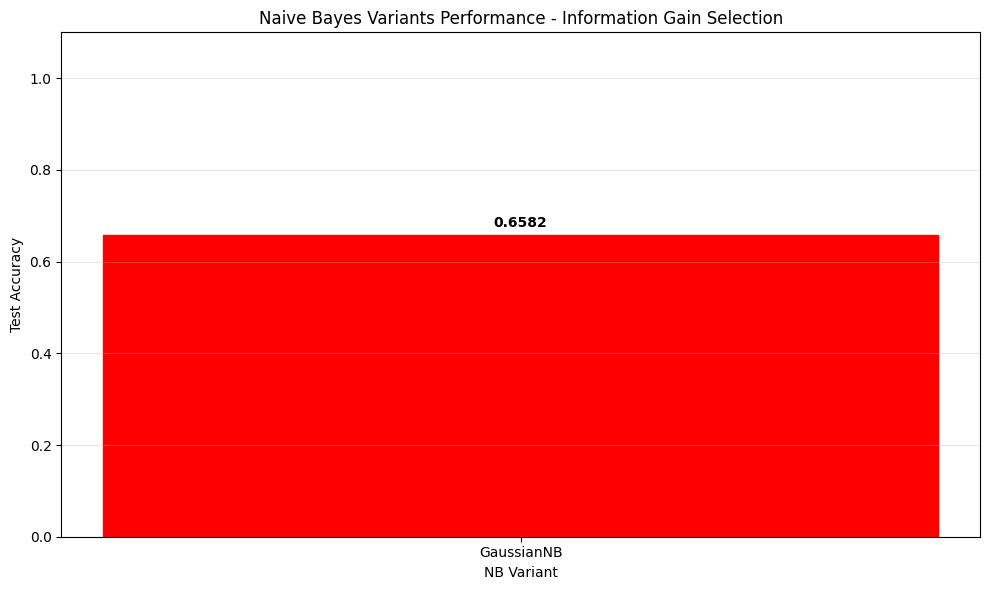

In [9]:
# Test 2: Information Gain Selected Features  
print("\n🚀 Starting Test 2: Information Gain Selected Features")
ig_results = evaluate_naive_bayes_configuration(
    X_train_ig, X_test_ig, y_train_encoded, y_test_encoded,
    "Information Gain Selection", param_grids, label_encoder
)
evaluation_results['Information_Gain'] = ig_results


🚀 Starting Test 3: PCA Analysis

EVALUATING: PCA
Training shape: (41162, 18)
Test shape: (10291, 18)

📋 Data Preprocessing for NB variants...

🔍 Testing NB Variants with Hyperparameter Optimization...
   Testing GaussianNB...
     Best CV score: 0.7259
     Best params: {'var_smoothing': 0.001}

🏆 Best variant: GaussianNB
   Best CV score: 0.7259
   Best parameters: {'var_smoothing': 0.001}
   Total optimization time: 5.32 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 0.0230 ± 0.0012 seconds
   Memory increase: 0.26 MB

📊 Performance Evaluation...
   Training Accuracy: 0.7256
   Test Accuracy: 0.7345
   Training F1 (macro): 0.7228
   Test F1 (macro): 0.7322
   Training F1 (weighted): 0.7238
   Test F1 (weighted): 0.7330

⚡ Inference Time Measurement...
   Mean inference time: 12.44 ± 1.35 ms
   Time per sample: 0.0012 ms
   Samples per second: 827105

💾 Memory Usage Analysis...
   Memory before: 3692.71 MB
   Memory after: 3710.43 MB
   Memory increase: 17.

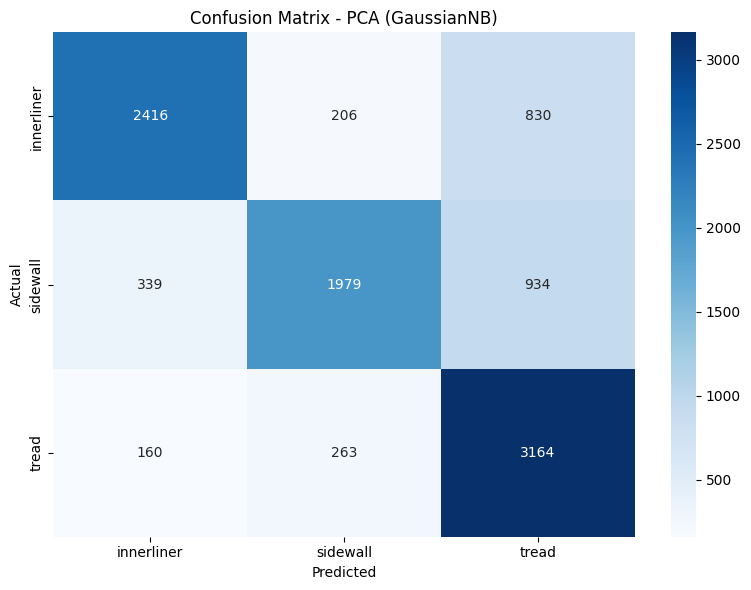


📈 NB Variants Performance Comparison...
   GaussianNB: 0.7345


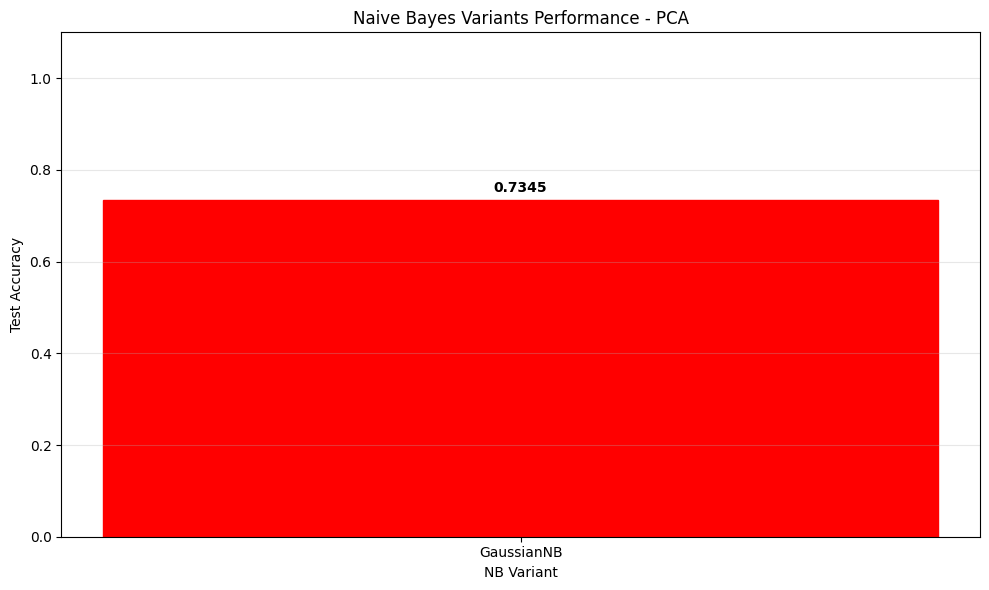

In [11]:
print("\n🚀 Starting Test 3: PCA Analysis")

# Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=18) # n_components chosen based on prior analysis (95% variance)
X_train_pca = pca.fit_transform(X_train, y_train_encoded)
X_test_pca = pca.transform(X_test)

pca_result = evaluate_naive_bayes_configuration(
    X_train_pca, X_test_pca, y_train_encoded, y_test_encoded,
    config_name='PCA', label_encoder=label_encoder, param_grids=param_grids)


EVALUATING: LDA
Training shape: (41162, 2)
Test shape: (10291, 2)

📋 Data Preprocessing for NB variants...

🔍 Testing NB Variants with Hyperparameter Optimization...
   Testing GaussianNB...
     Best CV score: 0.9772
     Best params: {'var_smoothing': 0.001}

🏆 Best variant: GaussianNB
   Best CV score: 0.9772
   Best parameters: {'var_smoothing': 0.001}
   Total optimization time: 3.79 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 0.0173 ± 0.0012 seconds
   Memory increase: 0.40 MB

📊 Performance Evaluation...
   Training Accuracy: 0.9770
   Test Accuracy: 0.9261
   Training F1 (macro): 0.9769
   Test F1 (macro): 0.9256
   Training F1 (weighted): 0.9770
   Test F1 (weighted): 0.9261

⚡ Inference Time Measurement...
   Mean inference time: 12.30 ± 1.03 ms
   Time per sample: 0.0012 ms
   Samples per second: 836516

💾 Memory Usage Analysis...
   Memory before: 3363.85 MB
   Memory after: 3393.46 MB
   Memory increase: 29.62 MB
   Peak memory usage: 4.07 MB

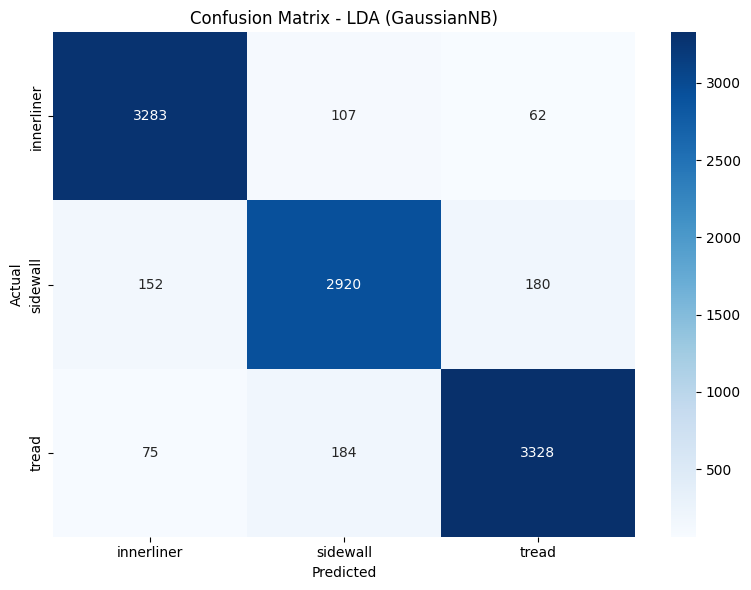


📈 NB Variants Performance Comparison...
   GaussianNB: 0.9261


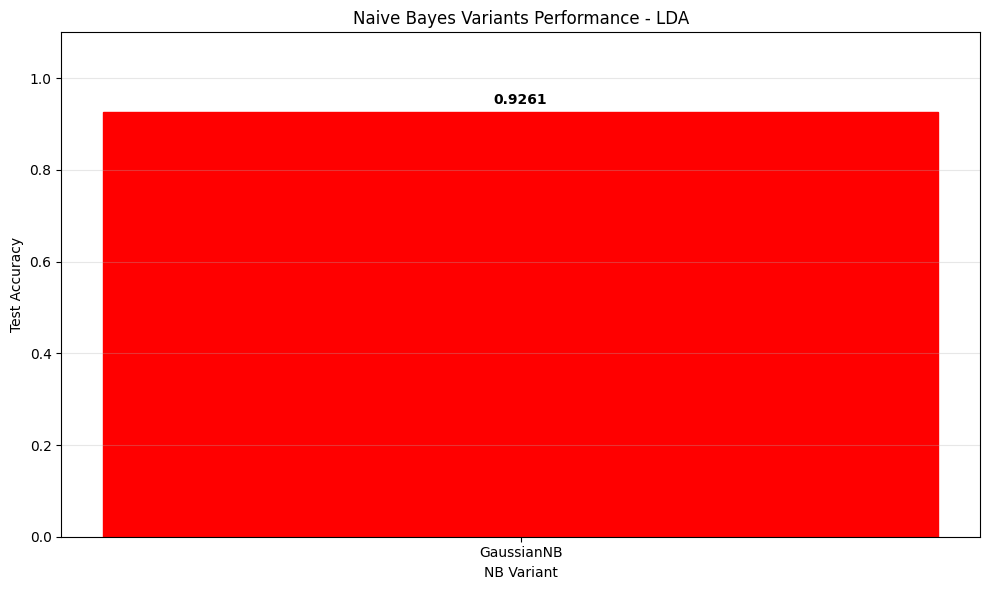

In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)  # n_components chosen based on prior analysis

X_train_lda = lda.fit_transform(X_train, y_train_encoded)
X_test_lda = lda.transform(X_test)

lda_result = evaluate_naive_bayes_configuration(
	X_train_lda, X_test_lda, y_train_encoded, y_test_encoded,
	config_name="LDA", label_encoder=label_encoder, param_grids=param_grids)

## 2. Naive Bayes met PCA gereduceerde features

COMPREHENSIVE NAIVE BAYES RESULTS COMPARISON
⚠️  Could not extract PCA results

NAIVE BAYES PERFORMANCE SUMMARY:
            Method  Test_Accuracy  Features  training_time_mean  inference_time_per_sample  memory_peak
LDA (2 components)        0.92606         2             0.01725                   0.000001     4.067686


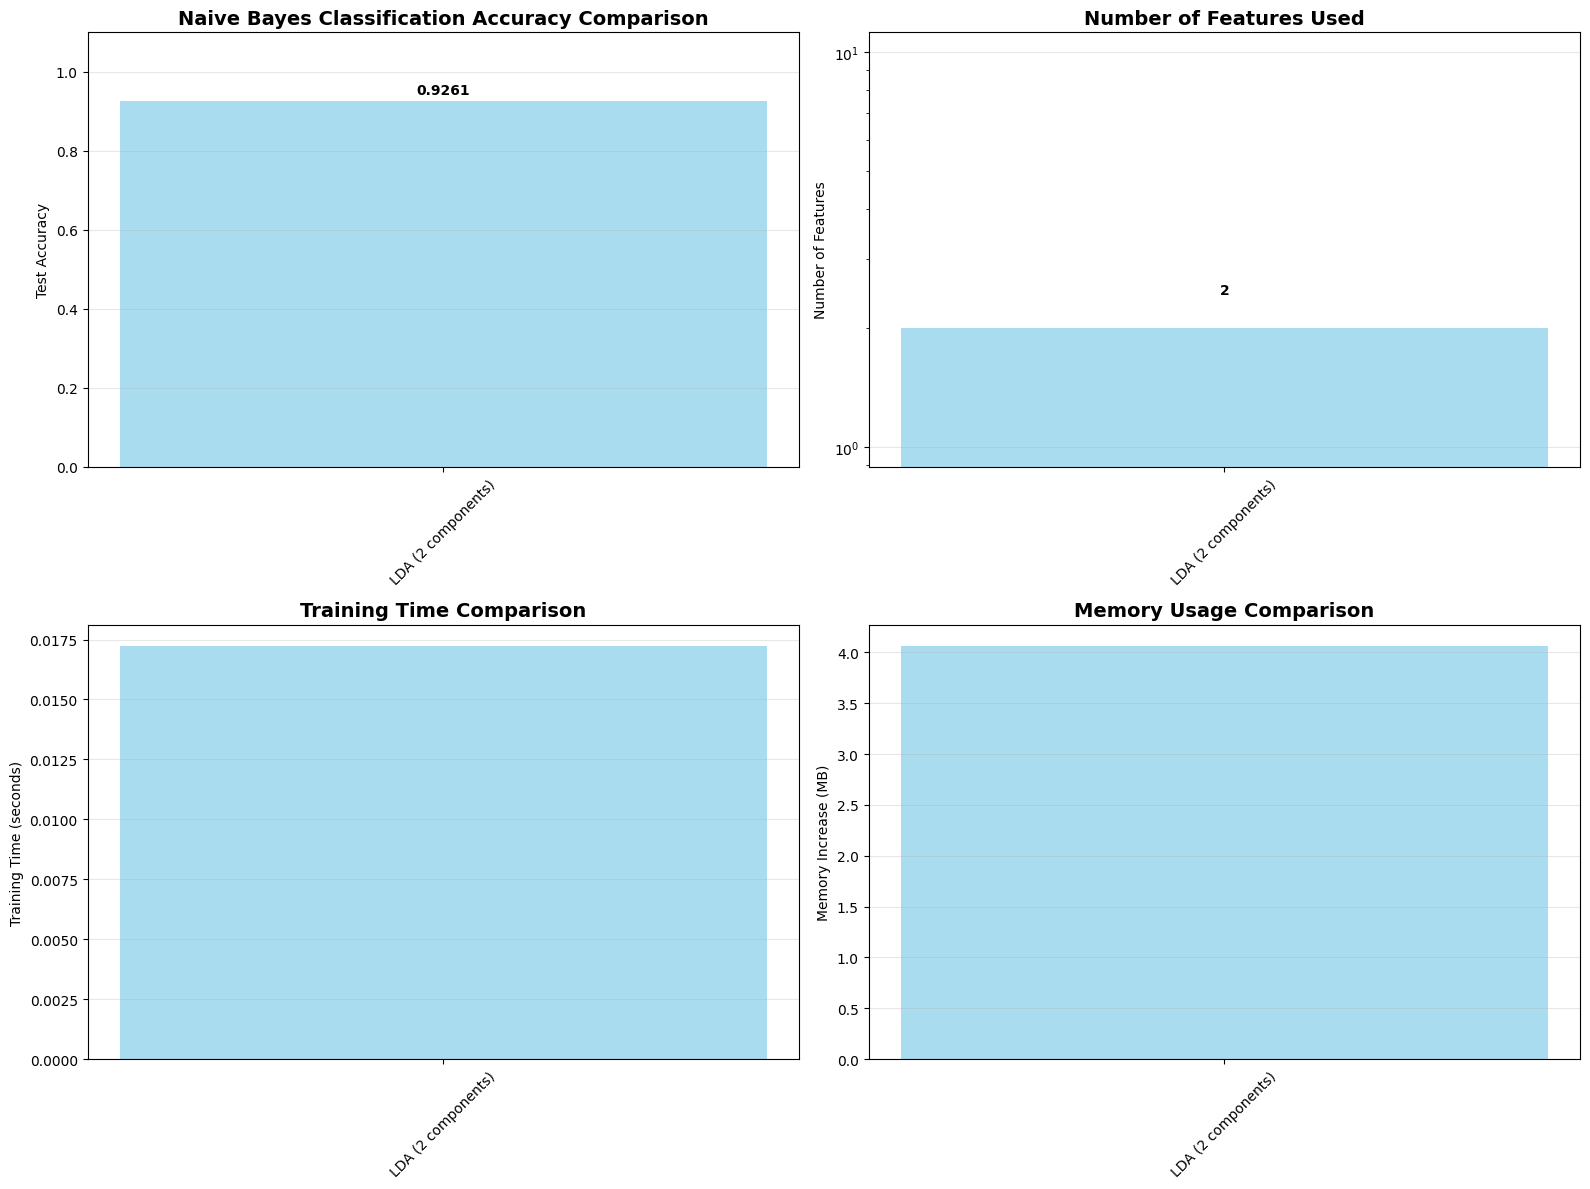

In [9]:
# Comprehensive Results Comparison
print("=" * 80)
print("COMPREHENSIVE NAIVE BAYES RESULTS COMPARISON")
print("=" * 80)

# Extract results from PCA and LDA analyses
try:
    evaluation_results['PCA'] = {
        'config_name': f'PCA (18 components)',
        'test_accuracy': pca_result['test_f1_weighted'],
        'n_features': 18,
        'training_time_mean': pca_result['training_time_mean'],
        'inference_time_per_sample': pca_result['inference_time_per_sample'],
        'memory_peak': pca_result['memory_peak'],
    }
except:
    print("⚠️  Could not extract PCA results")

try:
        evaluation_results['LDA'] = {
            'config_name': f'LDA (2 components)',
            'test_accuracy': lda_result['test_f1_weighted'],
            'n_features': 2,
            'training_time_mean': lda_result['training_time_mean'],
            'inference_time_per_sample': lda_result['inference_time_per_sample'],
            'memory_peak': lda_result['memory_peak'],
        }
except:
    print("⚠️  Could not extract LDA results")

# Create summary table
summary_data = []
for method_name, results in evaluation_results.items():
    if isinstance(results, dict) and 'test_accuracy' in results:
        summary_data.append({
            'Method': results.get('config_name', method_name),
            'Test_Accuracy': results['test_accuracy'],
            'Features': results['n_features'],
            'training_time_mean': results.get('training_time_mean', 'N/A'),
            'inference_time_per_sample': results.get('inference_time_per_sample', 'N/A'),
            'memory_peak': results.get('memory_peak', 'N/A'),
        })

if summary_data:
    results_df = pd.DataFrame(summary_data)
    print("\nNAIVE BAYES PERFORMANCE SUMMARY:")
    print("=" * 120)
    print(results_df.to_string(index=False))
    print("=" * 120)
    
    # Visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    methods = results_df['Method']
    accuracies = results_df['Test_Accuracy']
    features = results_df['Features']
    
    # 1. Accuracy comparison
    colors = ['skyblue', 'lightgreen', 'orange', 'pink'][:len(methods)]
    bars1 = ax1.bar(methods, accuracies, color=colors, alpha=0.7)
    ax1.set_title('Naive Bayes Classification Accuracy Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Test Accuracy')
    ax1.set_ylim(0, 1.1)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    
    for bar, accuracy in zip(bars1, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Feature count comparison
    bars2 = ax2.bar(methods, features, color=colors, alpha=0.7)
    ax2.set_title('Number of Features Used', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of Features')
    ax2.set_yscale('log')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3)
    
    for bar, feature_count in zip(bars2, features):
        ax2.text(bar.get_x() + bar.get_width()/2, feature_count * 1.2,
                 f'{feature_count}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Training time comparison (if available)
    training_times = [results_df['training_time_mean'].iloc[i] if results_df['training_time_mean'].iloc[i] != 'N/A' else 0 
                     for i in range(len(methods))]
    if any(t > 0 for t in training_times):
        bars3 = ax3.bar(methods, training_times, color=colors, alpha=0.7)
        ax3.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Training Time (seconds)')
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(axis='y', alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'Training time data\nnot available', 
                transform=ax3.transAxes, ha='center', va='center', fontsize=12)
        ax3.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
    
    # 4. Memory usage comparison (if available)
    memory_usage = [results_df['memory_peak'].iloc[i] if results_df['memory_peak'].iloc[i] != 'N/A' else 0 
                   for i in range(len(methods))]
    if any(m > 0 for m in memory_usage):
        bars4 = ax4.bar(methods, memory_usage, color=colors, alpha=0.7)
        ax4.set_title('Memory Usage Comparison', fontsize=14, fontweight='bold')
        ax4.set_ylabel('Memory Increase (MB)')
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(axis='y', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Memory usage data\nnot available', 
                transform=ax4.transAxes, ha='center', va='center', fontsize=12)
        ax4.set_title('Memory Usage Comparison', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()